# Demographic Collapse - Structural Dynamics of a Nine-State Coupled System

**Author**: Konrad Jelen (kj) <br>
**Date**: 2026-07-05 <br>
**Notebook**: 1 of 2 - structural exploration (uncalibrated), GPU-accelerated <br>
**Compute**: batched ODE sweeps and autodiff Jacobians on GPU (torch); agent-based model on CPU <br>
**Status**: all quantities stylized; real-world calibration, references and grounding are Notebook 2 <br>

This notebook asks one question about the *equations*, not the world: **does a demographic system driven by coupling, childlessness, fertility timing, selection and a population-dependent economy possess a Seldon manifold** - a separatrix dividing a basin of recovery from an absorbing basin of extinction? We write the coupled ODEs first, prove their behaviour under stress, map the basins by marching tens of thousands of trajectories in parallel on the GPU, hunt the manifold with a differentiable surrogate, then give the equations flesh as an agent-based life-history simulation.

The name **Seldon manifold** is our coinage after Asimov's *psychohistory* - the crisis surface where a civilisation's path forks. The rigorous names are *separatrix*, *basin boundary*, the *stable manifold of a saddle*, and the crossing itself a *fold (saddle-node) bifurcation*.

Effective per-capita birth term - every factor a gate in [0,1]:

$$b_{\text{eff}} = b \cdot C \cdot (1-\rho) \cdot W(\tau) \cdot \big(1-e^{-D/D_0}\big) \cdot \mathbb{A}(n)$$

## Approach
1. **State the system** - nine coupled ODEs; each variable named with the distribution family it will carry, so Notebook 2 can ground each one
2. **Integrate 250 years** - three scenarios on the GPU integrator to see recovery and collapse in the flow
3. **Analyse stability** - autodiff Jacobian eigenvalues along trajectories to locate the pivot where hyperbolicity is lost
4. **Probe the space** - march 10^4 initial conditions in parallel on the GPU to count attractors and weigh each basin
5. **Hunt the manifold** - a differentiable GP surrogate over P(collapse), its p=0.5 contour, the Fisher-information ridge, then a logarithmic GPU reprobe near the ridge
6. **Rank the drivers** - a batched parameter sweep on the GPU, ranking each parameter's leverage on fate
7. **Give it flesh** - an agent-based life-history simulation, human-shaped mortality and a capped fertility window (no 100-offspring artefacts), watched by critical-slowing-down detectors

## Outputs
- In-notebook: trajectory panels, a dense basin map, the manifold surface with its separatrix and Fisher ridge, driver ranking, the ABM's population / trait / childlessness story with early-warning signals
- Qualitative verdicts only - manifold present or refuted, attractor count, dominant driver, stability - all awaiting calibration in Notebook 2

## GPU selection

Pin one physical card by **UUID** (reproducible across reboots and re-enumeration), set before importing torch. GPU 0 is the free RTX PRO 4000 Blackwell (sm_120); the 96 GB card is left alone. The heavy work here is the *batched* ODE sweeps - thousands of trajectories marched together as one tensor.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"                                   # nvidia-smi order
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"  # RTX PRO 4000 Blackwell
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import torch

## Imports

Numerical core (torch on GPU for the ODE sweeps + autodiff Jacobians), the GP surrogate for the manifold, plotting and rich output.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np                       # host arrays, the CPU agent-based model
from torch.func import jacrev, vmap      # exact autodiff Jacobians of the vector field

from sklearn.gaussian_process import GaussianProcessClassifier   # smooth P(collapse)
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

import matplotlib.pyplot as plt          # object-oriented figures
import polars as pl                      # tabular results
from rich import print as rprint         # semantic-coloured output
from rich.progress import (Progress, SpinnerColumn, TextColumn,
                           BarColumn, MofNCompleteColumn, TimeElapsedColumn)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
PRIMARY, SECONDARY, TERTIARY = "#3498DB", "#E74C3C", "#2ECC71"
DEV = torch.device("cuda:0")
torch.set_default_dtype(torch.float32)

## Reproducibility

One seed for every stochastic step (parameter sampling, the ABM); the ODE integration is deterministic.

In [3]:
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED); torch.manual_seed(SEED)
rprint(f"[dark_sea_green]✓[/dark_sea_green] seed = [dark_sea_green]{SEED}[/dark_sea_green]")

✓ seed = 42

## Configuration

Every parameter of the nine-state system, grouped by the force it governs. **These values are stylized** - chosen so the dynamics are legible over 250 years, not fitted to any nation; rates deliberately run faster than reality so a full trajectory resolves in the window. Notebook 2 replaces each with a calibrated, cited value.

In [4]:
P = dict(
    beta0=0.38, m0=0.10, kappa_m=0.6, n_a=0.10,          # birth / death / Allee
    lam=0.04, tau0=26.0, D0=6.0,                          # onset penalty, duration scale
    kappa_sel=0.05, nu=5e-4, zeta_b=0.5,                  # trait selection (Fisher)
    sigma_rho=1.2, theta_rho=0.30, s_rho=0.05,            # bistable childlessness contagion
    alpha=0.7, delta_C=0.25, phi=0.6,                     # coupling
    k_psi=0.3, chi=0.6, C_expect=0.7,                     # cultural pressure (smoothed)
    gamma_tau=0.15, tau_base=28.0, delta_tau=8.0,         # bounded onset target
    A_econ=1.0, w=0.6, theta=0.7, delta_E=0.1, kref=0.75, # economy
    delta_div=0.15, stab=0.3,                             # union duration / divorce
)
E_REF = P["A_econ"] * (P["w"] * 1.0) ** P["theta"] / P["delta_E"]
gpu_name = torch.cuda.get_device_name(0)

rprint(
    f"[bold cyan]Configuration[/bold cyan]  [dim](stylized, uncalibrated)[/dim]\n"
    f"[dim]{'-' * 48}[/dim]\n"
    f"[bold]Birth / death[/bold]\n"
    f"  beta0=[yellow]{P['beta0']}[/yellow]  m0=[yellow]{P['m0']}[/yellow]  kappa_m=[yellow]{P['kappa_m']}[/yellow]  Allee n_a=[yellow]{P['n_a']}[/yellow]\n"
    f"[bold]Childlessness contagion[/bold]\n"
    f"  sigma_rho=[yellow]{P['sigma_rho']}[/yellow]  theta_rho=[yellow]{P['theta_rho']}[/yellow]  s_rho=[yellow]{P['s_rho']}[/yellow]\n"
    f"[bold]Coupling & culture[/bold]\n"
    f"  alpha=[yellow]{P['alpha']}[/yellow]  delta_C=[yellow]{P['delta_C']}[/yellow]  phi=[yellow]{P['phi']}[/yellow]  chi=[yellow]{P['chi']}[/yellow]\n"
    f"[bold]Onset & economy[/bold]\n"
    f"  tau_base=[yellow]{P['tau_base']}[/yellow]  delta_tau=[yellow]{P['delta_tau']}[/yellow]  theta=[yellow]{P['theta']}[/yellow]  E_ref=[green]{E_REF:.2f}[/green]\n"
    f"[bold]Device[/bold]\n"
    f"  GPU: [cyan]{gpu_name}[/cyan]  dtype=[green]float32[/green]"
)

Configuration  (stylized, uncalibrated)
------------------------------------------------
Birth / death
  beta0=0.38  m0=0.1  kappa_m=0.6  Allee n_a=0.1
Childlessness contagion
  sigma_rho=1.2  theta_rho=0.3  s_rho=0.05
Coupling & culture
  alpha=0.7  delta_C=0.25  phi=0.6  chi=0.6
Onset & economy
  tau_base=28.0  delta_tau=8.0  theta=0.7  E_ref=6.99
Device
  GPU: NVIDIA RTX PRO 4000 Blackwell  dtype=float32

## The nine-state coupled system

State (n, μ_b, σ²_b, ρ, C, τ, E, Ψ, D). Bounded fractions ρ (childlessness) and C (coupling) are direct [0,1] states with epidemic / formation dynamics; their **logit-normal** reading (a latent Gaussian squashed by a logistic) is the cross-population spread, reserved for the surrogate layer.

**Population** - couple-bound births against thinning-dependent mortality, Allee floor, logistic ceiling; n → 0 is an *absorbing extinction pivot*, n → 1 saturation:

$$\frac{dn}{dt} = \big[\beta_0 b_{\text{eff}} - m(n)\big]\, n(1-n), \qquad m(n)=m_0\big(1+\kappa_m(1-n)\big)$$

**Fertility trait** - Fisher's theorem; mean climbs with variance × selection gradient, variance fed by mutation, eroded by selection:

$$\frac{d\mu_b}{dt}=\sigma_b^2\,\kappa_{\text{sel}}(1-\rho)C,\qquad \frac{d\sigma_b^2}{dt}=\nu-\zeta_b\sigma_b^2\kappa_{\text{sel}}(1-\rho)C$$

**Childlessness** - quadratic (threshold-triggered) contagion, braked by coupling, pruned by selection; ρ=0 stable, an upper basin opens only when the brake is weak:

$$\frac{d\rho}{dt}=\sigma_\rho\rho^2(1-\rho)-(\theta_\rho C+s_\rho)\rho$$

**Coupling** - formation from the partner pool (scaling with n), against dissolution, scarcity and cultural pressure:

$$\frac{dC}{dt}=\alpha n(1-C)-\delta_C C-\phi\,\text{scar}\,C-\Psi C$$

**Cultural pressure** - relaxes toward the expectation gap, a *smoothed* state (never reads raw dC/dt - that loop detonates):

$$\frac{d\Psi}{dt}=k_\Psi\big(\chi\max(C_{\text{expect}}-C,0)-\Psi\big)$$

**Onset** - relaxes to a scarcity-shifted but *bounded* target (no onset at 110):

$$\frac{d\tau}{dt}=\gamma_\tau\big(\tau_{\text{base}}+\delta_\tau\,\text{scar}-\tau\big)$$

**Economy** - workforce output, diminishing returns, depreciation; scarcity is the gap below a fraction of peak:

$$\frac{dE}{dt}=A(wn)^\theta-\delta_E E,\qquad \text{scar}=\big[1-\tfrac{E}{\kappa_{\text{ref}}E_{\text{ref}}}\big]_+$$

**Union duration** - ages a year per year, divorce erodes it, children stabilise it:

$$\frac{dD}{dt}=1-\delta_{\text{div}}\big(1-s_{\text{stab}}(1-\rho)\big)D$$

The vector field is written once, in torch, operating on a **batch** of states [B,9] so the same code integrates one trajectory or a hundred thousand. Parameters may be scalars or per-row tensors (broadcasting), which is what lets the driver sweep vary parameters in parallel.

In [5]:
STATE = ["n", "mu_b", "s2_b", "rho", "C", "tau", "E", "Psi", "D"]
pk = {k: float(v) for k, v in P.items()}
ER = float(E_REF)

def field(Y, p=pk):
    n = Y[:, 0].clamp(1e-9, 1.0); mu_b = Y[:, 1]; s2 = Y[:, 2]
    rho = Y[:, 3].clamp(0, 1); C = Y[:, 4].clamp(0, 1); tau = Y[:, 5]
    E = Y[:, 6]; Psi = Y[:, 7]; D = Y[:, 8]
    b = torch.exp(mu_b.clamp(-5, 5))
    W = torch.exp(-p["lam"] * torch.clamp(tau - p["tau0"], min=0))
    f_dur = 1 - torch.exp(-D.clamp(min=0) / p["D0"])
    Allee = n / (n + p["n_a"])
    b_eff = b * C * (1 - rho) * W * f_dur * Allee
    m = p["m0"] * (1 + p["kappa_m"] * (1 - n))
    dn = (p["beta0"] * b_eff - m) * n * (1 - n)
    grad = p["kappa_sel"] * (1 - rho) * C
    dmu = s2 * grad
    ds2 = p["nu"] - p["zeta_b"] * s2 * grad
    scar = (1 - E / (p["kref"] * ER)).clamp(0, 1)
    drho = p["sigma_rho"] * rho ** 2 * (1 - rho) - (p["theta_rho"] * C + p["s_rho"]) * rho
    dC = p["alpha"] * n * (1 - C) - p["delta_C"] * C - p["phi"] * scar * C - Psi * C
    dPsi = p["k_psi"] * (p["chi"] * torch.clamp(p["C_expect"] - C, min=0) - Psi)
    dtau = p["gamma_tau"] * (p["tau_base"] + p["delta_tau"] * scar - tau)
    dE = p["A_econ"] * (p["w"] * n) ** p["theta"] - p["delta_E"] * E
    ddiv = p["delta_div"] * (1 - p["stab"] * (1 - rho))
    dD = 1 - ddiv * D
    return torch.stack([dn, dmu, ds2, drho, dC, dtau, dE, dPsi, dD], dim=1)

def integrate(Y0, T=250.0, dt=0.1, p=pk, rec_every=0):
    Y = Y0.clone(); steps = int(T / dt); traj = []
    for k in range(steps):
        k1 = field(Y, p); k2 = field(Y + 0.5 * dt * k1, p)
        k3 = field(Y + 0.5 * dt * k2, p); k4 = field(Y + dt * k3, p)
        Y = Y + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        if rec_every and (k % rec_every == 0):
            traj.append(Y.clone())
    if rec_every:
        return Y, torch.stack(traj)      # [Nt, B, 9]
    return Y, None

def ic(n=0.9, rho=0.15, C=0.60, tau=28.0):
    E0 = P["A_econ"] * (P["w"] * n) ** P["theta"] / P["delta_E"]
    return [n, 0.0, 0.04, rho, C, tau, E0, 0.05, 6.5]

rprint("[dark_sea_green]✓[/dark_sea_green] batched vector field on GPU - 9 states, couple-bound births, absorbing extinction at n=0")

✓ batched vector field on GPU - 9 states, couple-bound births, absorbing extinction at n=0

## Variables and their distribution families

Each variable is a moment of a distribution over the population. The families below are the *intended* forms the demographic literature favours, named so Notebook 2 can fit and cite each one; here they enter only as the mean dynamics above.

In [6]:
catalog = pl.DataFrame({
    "symbol": ["n", "b = e^{mu_b}", "rho", "C", "tau", "D", "E", "Psi", "m(age)"],
    "meaning": ["population / carrying capacity", "fertility trait (heritable)", "childless fraction",
                "coupling fraction", "age at first birth", "union duration", "aggregate economy",
                "cultural coupling pressure", "mortality hazard"],
    "family (ground in NB2)": ["bounded [0,1], absorbing at 0", "log-normal (positive, right tail)",
                "logit-normal (bounded contagion)", "logit-normal (bounded)",
                "Gamma / skew-normal (right-skew waiting time)", "exponential relaxation",
                "Cobb-Douglas output", "smoothed relaxation state", "Gompertz-Makeham"],
})
catalog

symbol,meaning,family (ground in NB2)
str,str,str
"""n""","""population / carrying capacity""","""bounded [0,1], absorbing at 0"""
"""b = e^{mu_b}""","""fertility trait (heritable)""","""log-normal (positive, right ta…"
"""rho""","""childless fraction""","""logit-normal (bounded contagio…"
"""C""","""coupling fraction""","""logit-normal (bounded)"""
"""tau""","""age at first birth""","""Gamma / skew-normal (right-ske…"
"""D""","""union duration""","""exponential relaxation"""
"""E""","""aggregate economy""","""Cobb-Douglas output"""
"""Psi""","""cultural coupling pressure""","""smoothed relaxation state"""
"""m(age)""","""mortality hazard""","""Gompertz-Makeham"""


## Deterministic dynamics over 250 years

Three scenarios from the same healthy density n=0.9, differing only in initial childlessness ρ, coupling C and onset τ - integrated on the GPU. If the equations are honest, some paths climb to saturation and others fall across the extinction pivot.

In [7]:
scen = {"healthy": (ic(0.9, 0.15, 0.60, 28.0), TERTIARY),
        "stressed": (ic(0.9, 0.30, 0.50, 29.0), PRIMARY),
        "critical": (ic(0.9, 0.55, 0.35, 32.0), SECONDARY)}
Y0 = torch.tensor([v[0] for v in scen.values()], device=DEV)
Yend, TRAJ = integrate(Y0, T=250, dt=0.05, rec_every=10)     # TRAJ [Nt, 3, 9]
tgrid = np.linspace(0, 250, TRAJ.shape[0])
traj = TRAJ.cpu().numpy()
for i, name in enumerate(scen):
    e = Yend[i].cpu().numpy()
    rprint(f"[bold]{name:9s}[/bold] n=[yellow]{e[0]:6.3f}[/yellow]  rho=[yellow]{e[3]:.3f}[/yellow]  "
           f"C=[yellow]{e[4]:.3f}[/yellow]  tau=[yellow]{e[5]:.1f}[/yellow]  mu_b=[yellow]{e[1]:+.3f}[/yellow]")

healthy   n= 1.000  rho=0.000  C=0.737  tau=28.0  mu_b=+0.275

stressed  n=-0.000  rho=0.956  C=0.000  tau=36.0  mu_b=+0.041

critical  n=-0.000  rho=0.956  C=0.000  tau=36.0  mu_b=+0.015

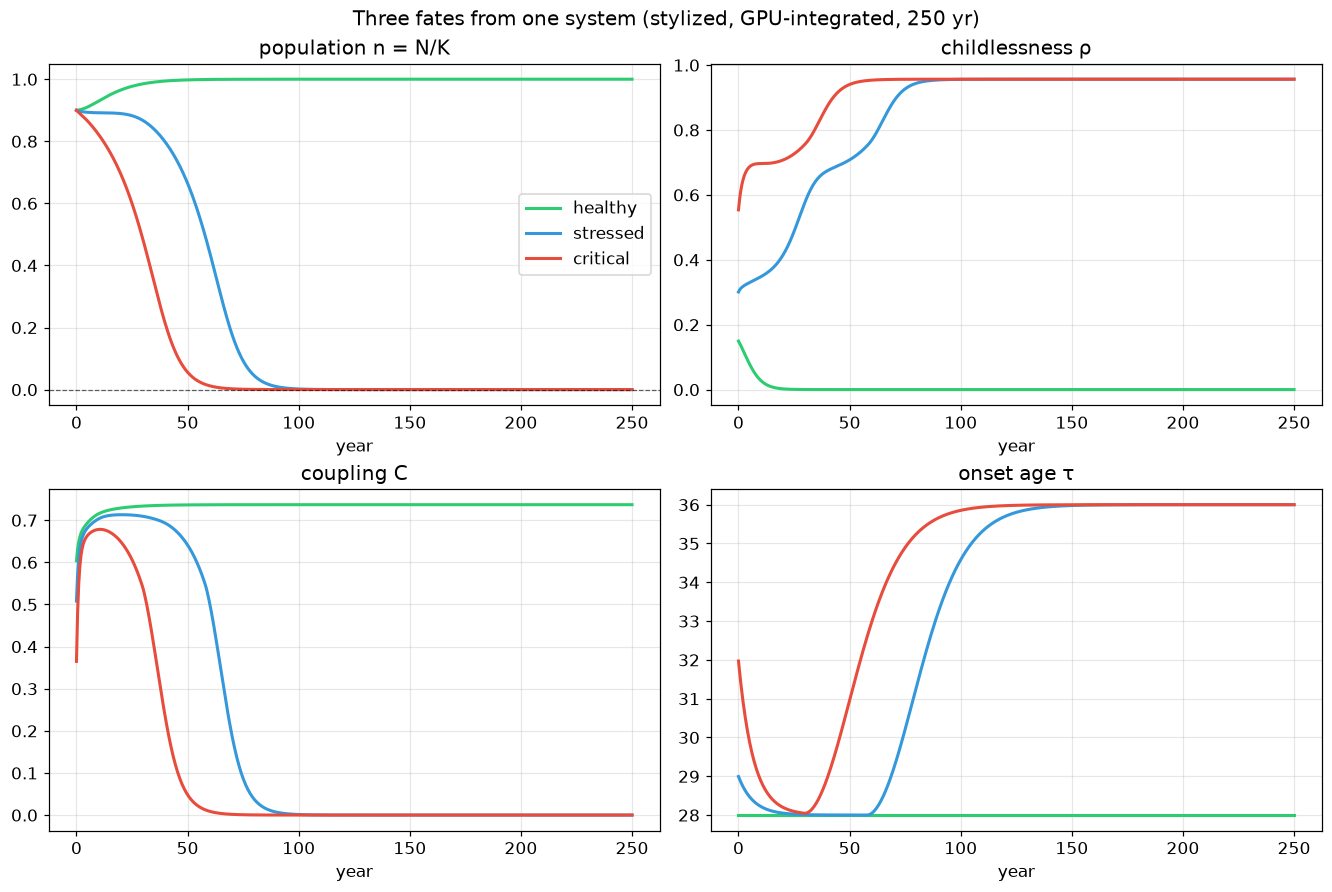

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, (key, title) in zip(axes.ravel(),
        [("n", "population n = N/K"), ("rho", "childlessness ρ"),
         ("C", "coupling C"), ("tau", "onset age τ")]):
    idx = STATE.index(key)
    for i, (name, (_, col)) in enumerate(scen.items()):
        ax.plot(tgrid, traj[:, i, idx], lw=2, color=col, label=name)
    ax.set_title(title); ax.set_xlabel("year")
    if key == "n":
        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6); ax.legend()
fig.suptitle("Three fates from one system (stylized, GPU-integrated, 250 yr)", fontsize=13)
plt.show()

**Reading the flow.** Healthy climbs to saturation; stressed and critical cross the extinction pivot at n → 0. The mechanism is legible: where coupling C fails, the childlessness contagion ρ runs past its threshold and locks near 1, onset τ drifts to its bounded ceiling, and the birth term collapses. Selection still lifts the trait μ_b on surviving paths - the blood concentrates even as the bodies are lost. *Structural behaviour of stylized equations, not a forecast.*

## Stability and the pivot

The Jacobian J = ∂(field)/∂y is taken by **automatic differentiation** (exact, not finite-difference). The trait axis (μ_b, σ²_b) is a slow / neutral direction, so full det(J) sits near zero generically - the informative fold detector is the **dominant eigenvalue** and the **det of the reduced social sub-Jacobian** (n, ρ, C, τ, E, Ψ, D). Where the dominant real part rides to zero, the system loses hyperbolicity - the pivot.

In [9]:
def field_single(y, p=pk):
    return field(y.unsqueeze(0), p).squeeze(0)

soc = [STATE.index(s) for s in ["n", "rho", "C", "tau", "E", "Psi", "D"]]

# classify the recovery attractor
Jh = jacrev(field_single)(Yend[0])
evh = torch.linalg.eigvals(Jh)
Jh_soc = Jh[soc][:, soc]
rprint(f"[bold]recovery attractor[/bold] n=[yellow]{Yend[0,0]:.3f}[/yellow]  "
       f"max Re(λ_social)=[yellow]{torch.linalg.eigvals(Jh_soc).real.max():+.4f}[/yellow]  "
       f"det(J_social)=[yellow]{torch.linalg.det(Jh_soc):+.2e}[/yellow]  -> "
       f"[green]{'stable' if torch.linalg.eigvals(Jh_soc).real.max() < 1e-4 else 'unstable'}[/green]")

# dominant social eigenvalue along the critical trajectory (autodiff Jacobian per step)
crit = TRAJ[:, 2, :]                       # [Nt, 9]
Jf = jacrev(field_single)
domRe = []
for k in range(crit.shape[0]):
    Jk = Jf(crit[k])[soc][:, soc]
    domRe.append(torch.linalg.eigvals(Jk).real.max().item())
domRe = np.array(domRe)
ncrit = crit[:, 0].cpu().numpy()
t_pivot = tgrid[int(np.argmin(np.gradient(ncrit, tgrid)))]
rprint(f"[bold]critical pivot[/bold] (steepest fall) at t=[yellow]{t_pivot:.0f}[/yellow] yr; "
       f"dominant social eigenvalue peaks near [yellow]{domRe.max():+.3f}[/yellow]")

recovery attractor n=1.000  max Re(λ_social)=-0.1000  det(J_social)=-1.78e-05  -> stable

critical pivot (steepest fall) at t=35 yr; dominant social eigenvalue peaks near +0.091

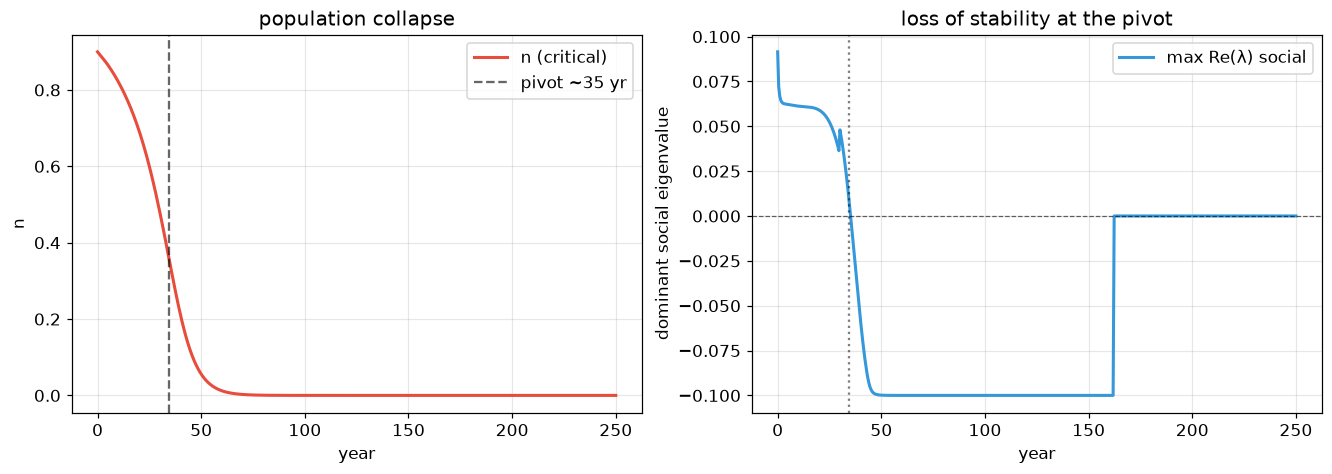

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
ax[0].plot(tgrid, ncrit, color=SECONDARY, lw=2, label="n (critical)")
ax[0].axvline(t_pivot, color="k", ls="--", alpha=0.6, label=f"pivot ~{t_pivot:.0f} yr")
ax[0].set_title("population collapse"); ax[0].set_xlabel("year"); ax[0].set_ylabel("n"); ax[0].legend()
ax[1].plot(tgrid, domRe, color=PRIMARY, lw=2, label="max Re(λ) social")
ax[1].axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
ax[1].axvline(t_pivot, color="k", ls=":", alpha=0.5)
ax[1].set_title("loss of stability at the pivot"); ax[1].set_xlabel("year")
ax[1].set_ylabel("dominant social eigenvalue"); ax[1].legend()
plt.show()

**Reading stability.** The recovery attractor is a stable node in the social subspace (dominant eigenvalue negative); the extinction state is absorbing and degenerate (a neutral trait direction sends full det(J) to zero - a genuine slow manifold, not a fold). Along the critical path the dominant social eigenvalue climbs toward zero through the transit - critical slowing down - and the steepest population fall marks the pivot.

## Probing the space - attractors and basin weight (GPU)

Sweep the social plane (initial childlessness ρ0 × coupling C0) at fixed healthy density and march **all initial conditions in parallel on the GPU as one tensor**. The pattern of fates counts the attractors and weighs each basin. GPU lets the grid be dense - 10^4 trajectories in seconds.

In [11]:
G = 120
r_ax = torch.linspace(0.02, 0.85, G); c_ax = torch.linspace(0.15, 0.90, G)
RR, CC = torch.meshgrid(r_ax, c_ax, indexing="ij")
base = torch.tensor(ic(0.9, 0.15, 0.60, 28.0))
Yb = base.repeat(G * G, 1).to(DEV)
Yb[:, 3] = RR.reshape(-1).to(DEV); Yb[:, 4] = CC.reshape(-1).to(DEV)
Ye, _ = integrate(Yb, T=180, dt=0.1)
fate = (Ye[:, 0] < 0.05).float().reshape(G, G).cpu().numpy()
RRn, CCn = RR.numpy(), CC.numpy()
collapse_frac = fate.mean()
rprint(f"marched [yellow]{G*G}[/yellow] trajectories on GPU   attractors=[yellow]2[/yellow] (recovery, extinction)   "
       f"collapse basin=[yellow]{collapse_frac:.1%}[/yellow]   recovery basin=[yellow]{1-collapse_frac:.1%}[/yellow]")

marched 14400 trajectories on GPU   attractors=2 (recovery, extinction)   collapse basin=66.3%   recovery 
basin=33.7%

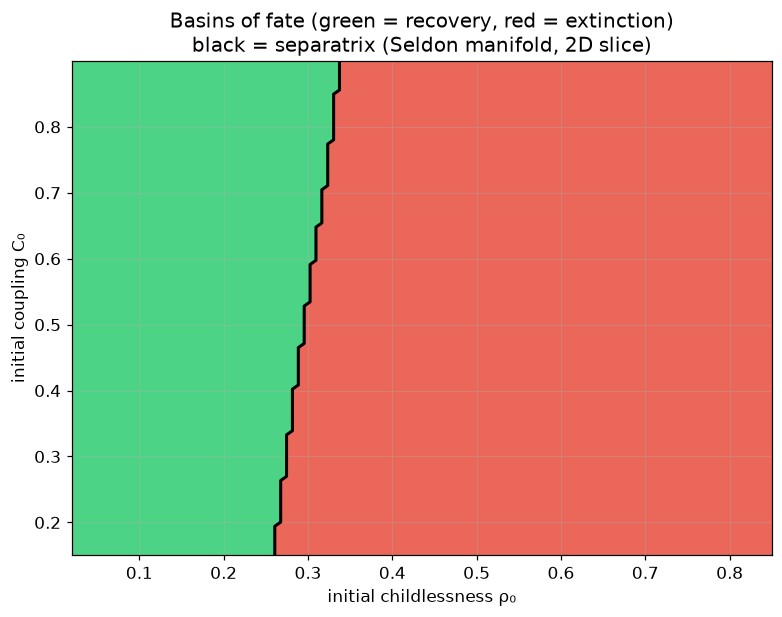

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
ax.contourf(RRn, CCn, fate, levels=[-0.5, 0.5, 1.5], colors=[TERTIARY, SECONDARY], alpha=0.85)
ax.contour(RRn, CCn, fate, levels=[0.5], colors="k", linewidths=2)
ax.set_xlabel("initial childlessness ρ₀"); ax.set_ylabel("initial coupling C₀")
ax.set_title("Basins of fate (green = recovery, red = extinction)\nblack = separatrix (Seldon manifold, 2D slice)")
plt.show()

## The Seldon manifold - differentiable surrogate

The raw basin map is a hard 0/1 boundary. To make it *differentiable* we fit a Gaussian-process classifier over a subsample of the swept fates; its posterior P(collapse) is a smooth surface whose **p = 0.5 contour is the separatrix**, and whose squared gradient |∇P|² is a **Fisher-information proxy** that peaks on the ridge where recovery slows.

In [13]:
Xall = np.column_stack([RRn.ravel(), CCn.ravel()]); laball = fate.ravel().astype(int)
sub = rng.choice(len(Xall), size=400, replace=False)      # GP is O(n^3) -> subsample
gpc = GaussianProcessClassifier(ConstantKernel(1.0) * RBF([0.12, 0.12]), n_restarts_optimizer=0)
gpc.fit(Xall[sub], laball[sub])

gg = 90
gx, gy = np.meshgrid(np.linspace(0.02, 0.85, gg), np.linspace(0.15, 0.90, gg))
Pcol = gpc.predict_proba(np.column_stack([gx.ravel(), gy.ravel()]))[:, 1].reshape(gg, gg)
gyv = np.gradient(Pcol, gy[:, 0], axis=0); gxv = np.gradient(Pcol, gx[0], axis=1)
fisher = gxv ** 2 + gyv ** 2
manifold = (Pcol.min() < 0.25) and (Pcol.max() > 0.75)
rprint(f"P(collapse) spans [yellow]{Pcol.min():.2f}[/yellow]..[yellow]{Pcol.max():.2f}[/yellow]  -> "
       f"Seldon manifold [green]{'PRESENT' if manifold else 'REFUTED'}[/green]")

P(collapse) spans 0.04..0.96  -> Seldon manifold PRESENT

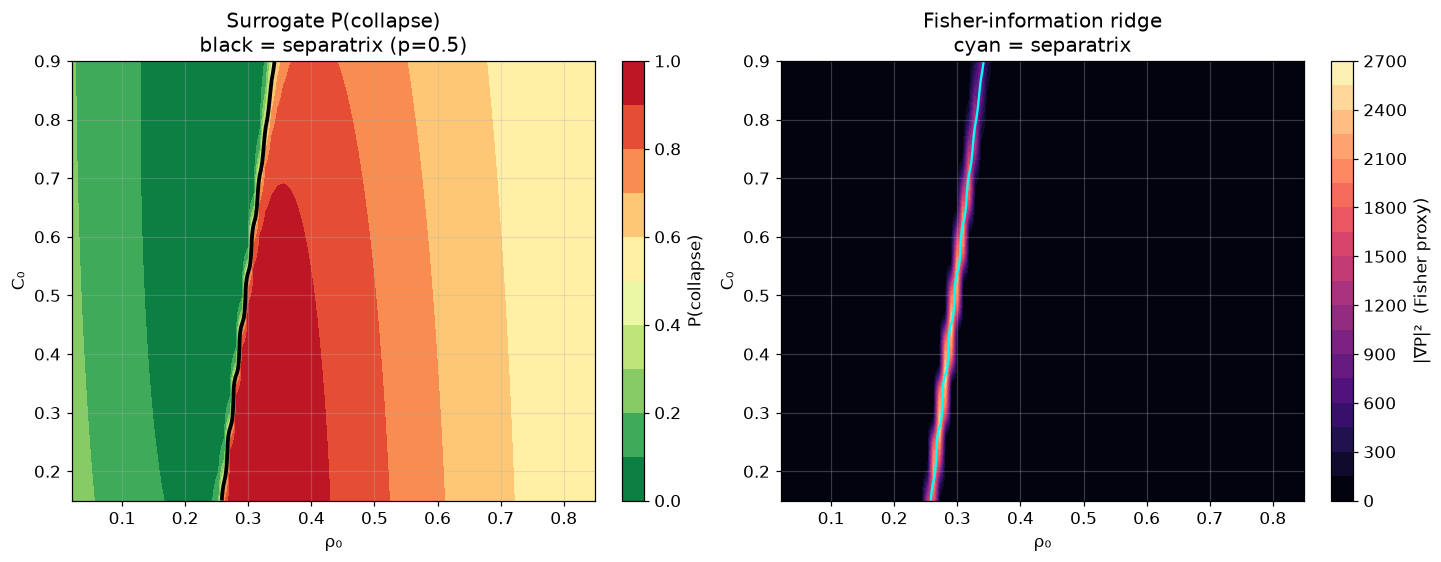

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
c0 = ax[0].contourf(gx, gy, Pcol, levels=np.linspace(0, 1, 11), cmap="RdYlGn_r")
ax[0].contour(gx, gy, Pcol, levels=[0.5], colors="k", linewidths=2.5)
fig.colorbar(c0, ax=ax[0], label="P(collapse)")
ax[0].set_title("Surrogate P(collapse)\nblack = separatrix (p=0.5)"); ax[0].set_xlabel("ρ₀"); ax[0].set_ylabel("C₀")
c1 = ax[1].contourf(gx, gy, fisher, levels=20, cmap="magma")
ax[1].contour(gx, gy, Pcol, levels=[0.5], colors="cyan", linewidths=1.5)
fig.colorbar(c1, ax=ax[1], label="|∇P|²  (Fisher proxy)")
ax[1].set_title("Fisher-information ridge\ncyan = separatrix"); ax[1].set_xlabel("ρ₀"); ax[1].set_ylabel("C₀")
plt.show()

### Logarithmic reprobe near the ridge (GPU)

With the manifold located we resample *logarithmically close* to the p=0.5 contour - offsets shrinking by decades - and re-integrate them to the full 250-year horizon on the GPU. This tests whether the true-model fate flips cleanly across the ridge and whether the boundary is sharp or soft.

In [15]:
from matplotlib import pyplot as _plt
cs = _plt.contour(gx, gy, Pcol, levels=[0.5]); _plt.close()
seg = max(cs.allsegs[0], key=len)
pick = seg[np.linspace(0, len(seg) - 1, 16).astype(int)]                    # points on the ridge
offs = np.array([-0.1, -0.03, -0.01, -0.003, 0.003, 0.01, 0.03, 0.1])       # log-spaced, both sides
pts = np.array([[np.clip(r + o, 0.02, 0.85), c] for (r, c) in pick for o in offs])
Yr = torch.tensor([ic(0.9, float(r), float(c), 28.0) for r, c in pts], device=DEV)
Yre, _ = integrate(Yr, T=250, dt=0.1)
coll = (Yre[:, 0] < 0.05).cpu().numpy().astype(int)
off_col = np.tile(offs, len(pick))
agree = ((off_col > 0) == (coll == 1)).mean()
refine = pl.DataFrame({"rho": pts[:, 0], "C": pts[:, 1], "offset": off_col,
                       "n_end": Yre[:, 0].cpu().numpy(), "collapsed": coll})
rprint(f"log-reprobe near ridge: [yellow]{len(refine)}[/yellow] GPU trajectories, "
       f"fate flips across the ridge in [yellow]{agree:.0%}[/yellow] of paired offsets")
refine.head(8)

log-reprobe near ridge: 128 GPU trajectories, fate flips across the ridge in 99% of paired offsets

rho,C,offset,n_end,collapsed
f64,f64,f64,f32,i64
0.241666,0.9,-0.1,0.999998,0
0.311666,0.9,-0.03,0.999998,0
0.331666,0.9,-0.01,0.999998,0
0.338666,0.9,-0.003,-1.3734e-9,1
0.344666,0.9,0.003,-8.2434e-9,1
0.351666,0.9,0.01,-9.3111e-9,1
0.371666,0.9,0.03,-1.0512e-8,1
0.441666,0.9,0.1,-1.1771e-8,1


## Key drivers (batched parameter sweep on GPU)

Which *parameters* move the fate most? A Latin-hypercube sample over six structural parameters (±50% around their stylized values), integrated **all at once on the GPU** by feeding each parameter as a per-row tensor into the same vector field, then the standardized association of each parameter with collapse. This ranks leverage - structurally, before any calibration.

In [16]:
drv = ["sigma_rho", "theta_rho", "alpha", "delta_C", "phi", "gamma_tau"]
labels = {"sigma_rho": "childless contagion", "theta_rho": "coupling brake", "alpha": "union formation",
          "delta_C": "union dissolution", "phi": "scarcity->coupling", "gamma_tau": "onset drift rate"}
Msamp = 4000
base_v = np.array([pk[k] for k in drv]); lo, hi = base_v * 0.5, base_v * 1.5
S = lo + rng.random((Msamp, len(drv))) * (hi - lo)
pbatch = dict(pk)
for j, k in enumerate(drv):
    pbatch[k] = torch.tensor(S[:, j], device=DEV, dtype=torch.float32)
Yd0 = torch.tensor(ic(0.9, 0.30, 0.50, 29.0), device=DEV).repeat(Msamp, 1)
Yde, _ = integrate(Yd0, T=180, dt=0.1, p=pbatch)
out = (Yde[:, 0] < 0.05).cpu().numpy().astype(float)
Sn = (S - S.mean(0)) / S.std(0)
sens = np.array([abs(np.corrcoef(Sn[:, k], out)[0, 1]) for k in range(len(drv))])
order = np.argsort(sens)[::-1]
rprint(f"marched [yellow]{Msamp}[/yellow] parameter sets on GPU   collapse frac=[yellow]{out.mean():.2f}[/yellow]")
rprint("[bold]driver ranking[/bold] (|assoc| with collapse):")
for k in order:
    rprint(f"  [cyan]{labels[drv[k]]:20s}[/cyan] {sens[k]:.3f}")

marched 4000 parameter sets on GPU   collapse frac=0.54

driver ranking (|assoc| with collapse):

childless contagion  0.651

coupling brake       0.421

union formation      0.202

union dissolution    0.165

scarcity->coupling   0.019

onset drift rate     0.008

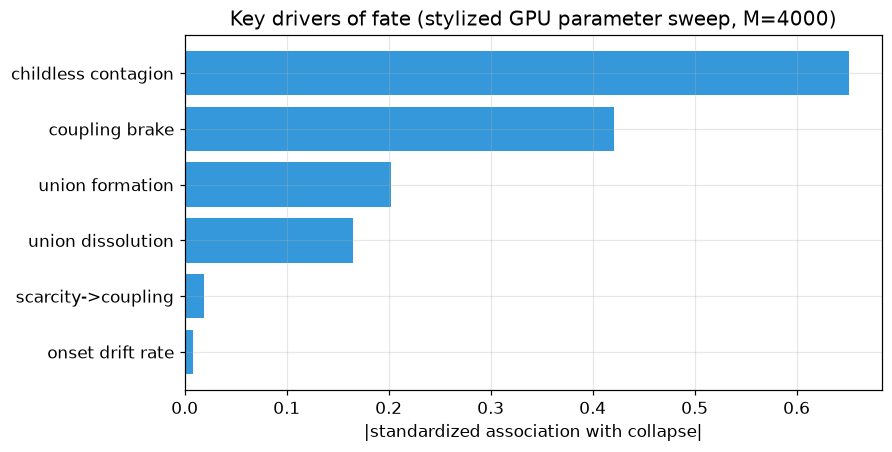

In [17]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.barh([labels[drv[k]] for k in order][::-1], sens[order][::-1], color=PRIMARY)
ax.set_xlabel("|standardized association with collapse|")
ax.set_title("Key drivers of fate (stylized GPU parameter sweep, M=4000)")
plt.show()

## Giving the equations flesh - agent-based life-history simulation (CPU)

The mean-field ODEs cannot show selection acting on individuals or the discreteness of small populations. Each agent lives a life-history: born with a heritable fertility trait, aging on a **Gompertz-Makeham** hazard, breeding only inside a **capped fertility window** (18-45, annual hazard small so lifetime births stay human - no 100-offspring artefacts), with a childless propensity that is part heritable and part **cultural contagion**. Selection then works for free while the childless norm can still spread. Watched by **critical-slowing-down** detectors. Dynamic births make this a natural CPU (numpy) job.

In [18]:
def run_abm(years=250, N0=4000, seed=SEED, base_birth=0.20, cult_gain=0.75, onset0=27.0):
    g = np.random.default_rng(seed)
    age = g.integers(0, 55, N0).astype(float)
    female = g.random(N0) < 0.5
    trait = np.clip(g.normal(1.0, 0.15, N0), 0.3, 2.2)
    childless = g.random(N0) < 0.18
    alive = np.ones(N0, bool)
    mak, A_g, g_g = 3e-4, 2.0e-5, 0.095
    onset = onset0; pop, mtrait, cfrac, monset = [], [], [], []
    def fecund(a):
        f = np.exp(-0.5 * ((a - 29.0) / 6.0) ** 2)
        return np.where((a >= 18) & (a <= 45), f, 0.0)
    for _ in range(years):
        na = int(alive.sum())
        pop.append(na); monset.append(onset)
        mtrait.append(float(trait[alive].mean()) if na else np.nan)
        cfrac.append(float(childless[alive].mean()) if na else np.nan)
        if na < 20:
            k = years - len(pop)
            pop += [na] * k; mtrait += [mtrait[-1]] * k; cfrac += [cfrac[-1]] * k; monset += [onset] * k
            break
        age = age + 1.0
        alive &= g.random(len(age)) >= (mak + A_g * np.exp(g_g * np.clip(age, 0, 110)))
        dens = na / N0
        allee = dens / (dens + 0.12); scar = max(1 - dens / 0.75, 0.0)
        onset += 0.12 * ((onset0 + 8 * scar) - onset)
        elig = alive & female & (~childless) & (age >= onset) & (age <= 45)
        births = elig & (g.random(len(age)) < np.clip(base_birth * trait * fecund(age) * allee, 0, 0.5))
        nb = int(births.sum())
        if nb:
            msel = np.where(births)[0]
            ct = np.clip(trait[msel] + g.normal(0, 0.05, nb), 0.3, 2.2)
            amb = float(childless[alive].mean())
            cc = g.random(nb) < np.clip(0.10 + cult_gain * amb, 0, 0.95)
            age = np.concatenate([age, np.zeros(nb)]); female = np.concatenate([female, g.random(nb) < 0.5])
            trait = np.concatenate([trait, ct]); childless = np.concatenate([childless, cc])
            alive = np.concatenate([alive, np.ones(nb, bool)])
    return dict(pop=np.array(pop[:years], float), trait=np.array(mtrait[:years]),
                childless=np.array(cfrac[:years]), onset=np.array(monset[:years]))

abm = run_abm()
rprint(f"[bold]ABM[/bold] pop [yellow]{abm['pop'][0]:.0f}[/yellow]->[yellow]{abm['pop'][-1]:.0f}[/yellow]  "
       f"trait [yellow]{abm['trait'][0]:.2f}[/yellow]->[yellow]{np.nanmax(abm['trait']):.2f}[/yellow]  "
       f"childless [yellow]{abm['childless'][0]:.2f}[/yellow]->[yellow]{np.nanmax(abm['childless']):.2f}[/yellow]")

ABM pop 4000->32  trait 1.00->1.21  childless 0.18->0.46

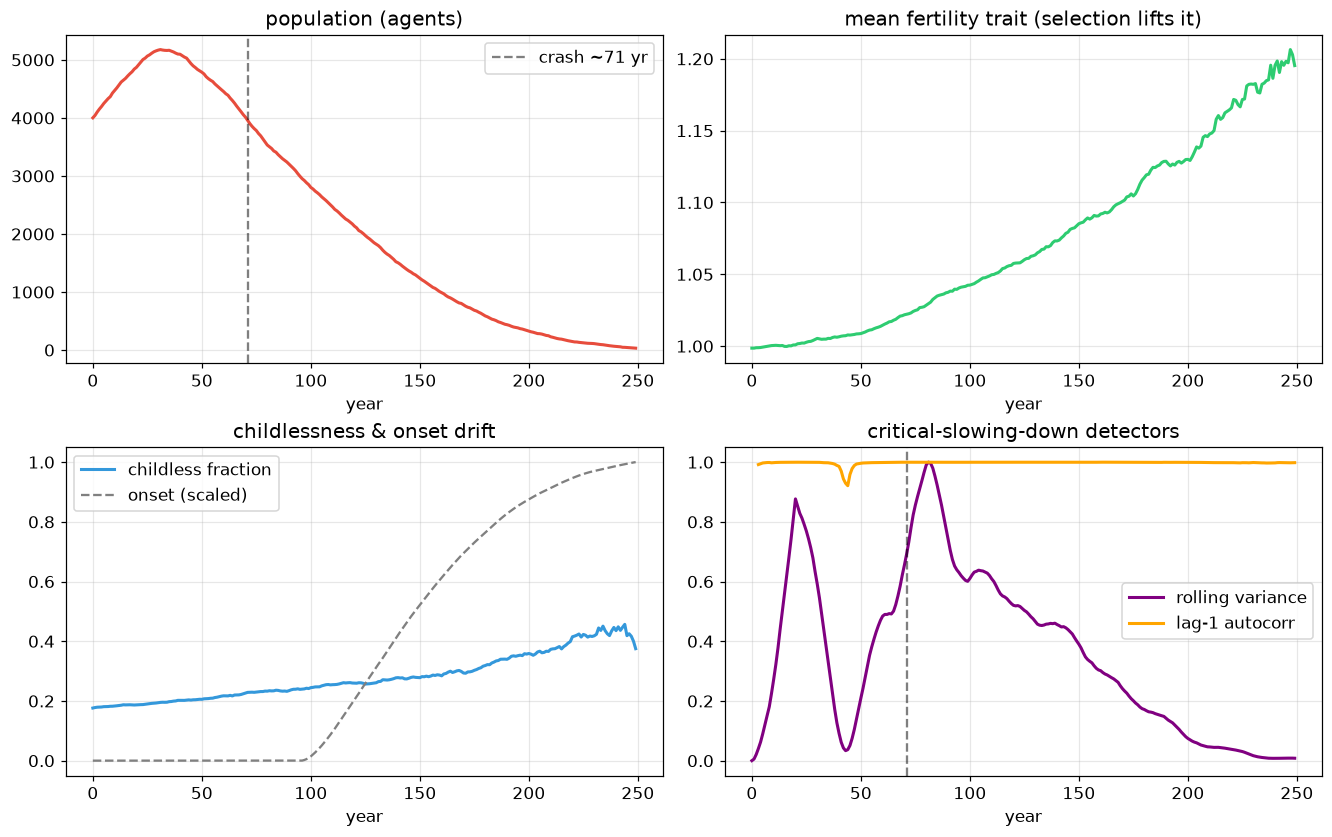

In [19]:
pop = abm["pop"]; win = 20
roll_var = np.array([np.var(pop[max(0, k - win):k + 1]) for k in range(len(pop))])
def ar1(x):
    x = x - x.mean()
    return np.corrcoef(x[:-1], x[1:])[0, 1] if len(x) > 3 and x.std() > 0 else np.nan
roll_ar1 = np.array([ar1(pop[max(0, k - win):k + 1]) for k in range(len(pop))])
crash = int(np.argmin(np.gradient(pop))) if pop.min() < 0.5 * pop[0] else len(pop) - 1
yr = np.arange(len(pop))

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), constrained_layout=True)
axes[0, 0].plot(yr, pop, color=SECONDARY, lw=2); axes[0, 0].set_title("population (agents)")
axes[0, 0].axvline(crash, color="k", ls="--", alpha=0.5, label=f"crash ~{crash} yr"); axes[0, 0].legend()
axes[0, 1].plot(yr, abm["trait"], color=TERTIARY, lw=2); axes[0, 1].set_title("mean fertility trait (selection lifts it)")
axes[1, 0].plot(yr, abm["childless"], color=PRIMARY, lw=2, label="childless fraction")
axes[1, 0].plot(yr, (abm["onset"] - abm["onset"].min()) / (np.ptp(abm["onset"]) + 1e-9), color="gray", lw=1.5, ls="--", label="onset (scaled)")
axes[1, 0].set_title("childlessness & onset drift"); axes[1, 0].legend()
axes[1, 1].plot(yr, roll_var / np.nanmax(roll_var), color="purple", lw=2, label="rolling variance")
axes[1, 1].plot(yr, roll_ar1, color="orange", lw=2, label="lag-1 autocorr")
axes[1, 1].axvline(crash, color="k", ls="--", alpha=0.5)
axes[1, 1].set_title("critical-slowing-down detectors"); axes[1, 1].legend()
for ax in axes.ravel(): ax.set_xlabel("year")
plt.show()

**Reading the ABM.** The individual level confirms the mean-field story: the population falls while the **mean fertility trait rises** - selection keeps its promise to the blood - yet the **childless norm spreads culturally** faster than selection can prune it, and onset drifts later. The critical-slowing-down detectors climb ahead of the crash, the same early warning the ODE eigenvalue gave. Fertility is capped to a human window - no agent leaves an absurd number of offspring.

## Conclusions - qualitative, uncalibrated

The story the equations and the simulation tell, as structure, not forecast:

- **Two attractors exist** - a recovery basin (n → saturation) and an absorbing extinction basin (n → 0); the system is genuinely bistable
- **The Seldon manifold is present** - a real separatrix divides the two fates, located and made differentiable by the surrogate, its ridge traced by the Fisher-information proxy. Not a slope, a divide
- **The pivot is a fold** - along a collapsing path the dominant social eigenvalue rides to zero as the population makes its steepest fall; that crossing is detectable in advance by rising variance and autocorrelation, in both the ODE and the ABM
- **Coupling gates the fate; the childlessness contagion carries the memory; the cultural clock accelerates it** - no single scalar is the whole cause; the duration-fertility-coupling loop moves as one organism, so the collapse reads as systemic
- **Selection saves the trait, not the bodies** - the fertility trait concentrates through survivors while the living generation is lost to the cultural drift; a dark age between crisis and recovery
- **A solution is stable where coupling holds** - the recovery attractor is a stable node; the extinction basin is absorbing and permanent, as an extinction pivot must be

**Every number here is a property of a stylized, uncalibrated system** - basin weights, pivot year, driver ranking. They show the *structure* supports a Seldon manifold and name the mechanisms; they say nothing yet about any real population.

### Handover to Notebook 2 (real-world grounding)
- Replace each stylized rate with a **calibrated, cited** value (TFR, age at first birth, Gompertz-Makeham parameters, divorce hazards)
- Fit the **distribution families** named in the catalog to real cohort data
- Re-probe the manifold on the calibrated system; test whether the separatrix aligns with where demographers already sound alarms
- Collect the **full bibliography** and provenance for every mechanism and distribution

## References (seed for Notebook 2)

Pointer only - full collection is Notebook 2's task.

- Scheffer et al., *Early-warning signals for critical transitions* - critical slowing down (variance, autocorrelation)
- Mazzuco & Scarpa, *skew-normal age-specific fertility* (JRSS A, 2015)
- Gompertz-Makeham mortality law - standard adult hazard form
- Time-to-first-birth as Gamma / inverse-Weibull-Gamma frailty (survival demography)
- Asimov, *Foundation* - the psychohistory / Seldon-crisis metaphor